In [1]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("./WS_Preprocessed/data/dataset_preprocessed_run_0.pkl", "rb") as f:
    X_train, y_train, X_val, y_val, X_test, y_test = pickle.load(f)

In [3]:
########################
### General Indexing ###
########################

# There are 3 independent tensors!
jet_tensor_id=0
jet_trk_tensor_id=1
trk_tensor_id=2

# Each tensor has 3 possible indicies!
Event_no=0
Jet_no=0
Trk_no=0

# There are 2 independent labels!
jet_labels=0
trk_labels=1

# Jets have 2 labels!
Efrac_id=0
Mfrac_id=1

In [4]:
print("X_train Indices Reference:")
print("\tNum Events: ", len(X_train))
print("\tNum Tensors: ", len(X_train[Event_no]), "(Jet, trk-jet, flat trk)")
print("\tNum Jet Feats: ", len(X_train[Event_no][jet_tensor_id][Jet_no]))
print("\tNum Trk Feats: ", len(X_train[Event_no][jet_trk_tensor_id][Jet_no][Trk_no]))
print()
print("y_train Indices Reference:")
print("\tNum Events: ", len(y_train))
print("\tNum Jets: ", len(y_train[Event_no][jet_labels]))
print("\tNum Trks: ", len(y_train[Event_no][trk_labels]))
print("Event",Event_no,":")
print("\tNum Jets: ", len(X_train[Event_no][jet_tensor_id]))
print("\tNum Trks Jet: ", len(X_train[Event_no][jet_trk_tensor_id][Jet_no]))
print("\tNum Trks Event: ", len(X_train[Event_no][trk_tensor_id]))
print()

X_train Indices Reference:
	Num Events:  700
	Num Tensors:  3 (Jet, trk-jet, flat trk)
	Num Jet Feats:  4
	Num Trk Feats:  6

y_train Indices Reference:
	Num Events:  700
	Num Jets:  42
	Num Trks:  745
Event 0 :
	Num Jets:  42
	Num Trks Jet:  25
	Num Trks Event:  745



In [27]:
# Variable number of jets per event. Each jet has 4 features and 2 continuous labels
jet_pT=[]
jet_eta=[]
jet_phi=[]
jet_m=[]
jet_Efrac=[]
jet_Mfrac=[]

# Variable number of tracks per jet. Each jet-trk has 6 features
jet_trk_pT=[]
jet_trk_eta=[]
jet_trk_phi=[]
jet_trk_q=[]
jet_trk_d0=[]
jet_trk_z0=[]

# Variable number of tracks per event. Each trk has 6 features and 1 binary label
trk_pT=[]
trk_eta=[]
trk_phi=[]
trk_q=[]
trk_d0=[]
trk_z0=[]
trk_isPU=[]

num_jets_in_event = []
num_trks_in_jet = []

num_events=len(y_train)
for event in range(num_events):
    
    num_jets=len(y_train[event][jet_labels])
    num_jets_in_event.append(num_jets)
    for jet in range(num_jets):
        jet_pT.append(X_train[event][jet_tensor_id][jet][0].numpy())
        jet_eta.append(X_train[event][jet_tensor_id][jet][1].numpy())
        jet_phi.append(X_train[event][jet_tensor_id][jet][2].numpy())
        jet_m.append(X_train[event][jet_tensor_id][jet][3].numpy())
        
        jet_Efrac.append(y_train[event][jet_labels][jet][Efrac_id].numpy())
        jet_Mfrac.append(y_train[event][jet_labels][jet][Mfrac_id].numpy())
        
        num_trks_per_jet=len(X_train[event][jet_trk_tensor_id][jet])
        print(num_trks_per_jet)
        num_trks_in_jet.append(num_trks_per_jet)
        for trk in range(num_trks_per_jet):
            jet_trk_pT.append(X_train[event][jet_trk_tensor_id][jet][trk][0].numpy())
            jet_trk_eta.append(X_train[event][jet_trk_tensor_id][jet][trk][1].numpy())
            jet_trk_phi.append(X_train[event][jet_trk_tensor_id][jet][trk][2].numpy())
            jet_trk_q.append(X_train[event][jet_trk_tensor_id][jet][trk][3].numpy())
            jet_trk_d0.append(X_train[event][jet_trk_tensor_id][jet][trk][4].numpy())
            jet_trk_z0.append(X_train[event][jet_trk_tensor_id][jet][trk][5].numpy())
            
    num_trks_per_event=len(y_train[event][trk_labels])
    for trk in range(num_trks_per_event):
        trk_pT.append(X_train[event][trk_tensor_id][trk][0].numpy())
        trk_eta.append(X_train[event][trk_tensor_id][trk][1].numpy())
        trk_phi.append(X_train[event][trk_tensor_id][trk][2].numpy())
        trk_q.append(X_train[event][trk_tensor_id][trk][3].numpy())
        trk_d0.append(X_train[event][trk_tensor_id][trk][4].numpy())
        trk_z0.append(X_train[event][trk_tensor_id][trk][5].numpy())
        trk_isPU.append(y_train[event][trk_labels][trk][0].numpy())

25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
3

39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
51
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
48
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
37
37
37
37
37
37
37
37
37
37
37
3

35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
35
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
4

32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
38
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
54
34
34
34
34
3

37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
44
4

...

42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
3

23
23
23
23
23
23
23
23
23
23
23
23
23
23
23
23
23
23
23
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
42
40
40
40
40
40
40
40
40
40
40
40
40
40
40
40
40
40
40
40
4

29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
29
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
33
40
40
40
40
40
40
40
40
40
4

31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
43
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
27
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
31
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
4

32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
30
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
41
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
34
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
28
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
45
4

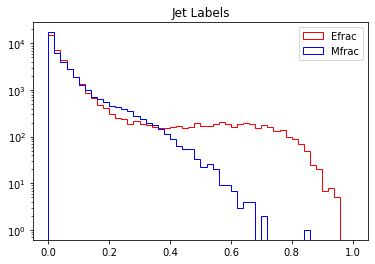

In [6]:
plt.title("Jet Labels")
plt.hist(np.ravel(jet_Efrac),bins=50,range=(0,1),histtype='step',color='r',label="Efrac")
plt.hist(np.ravel(jet_Mfrac),bins=50,range=(0,1),histtype='step',color='b',label="Mfrac")
plt.legend()
plt.yscale('log')
plt.show()

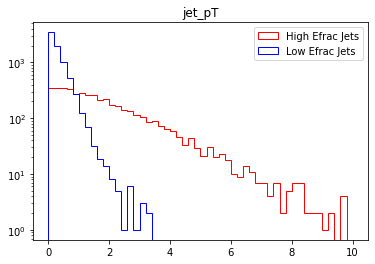

In [7]:
plt.title("jet_pT")
jet_pT=np.array(jet_pT)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_pT[jet_Efrac>0.2],bins=50,range=(0,10),histtype='step',color='r',label="High Efrac Jets")
plt.hist(jet_pT[jet_Efrac<=0.2],bins=50,range=(0,10),histtype='step',color='b',label="Low Efrac Jets")
plt.legend()
plt.yscale('log')
plt.show()

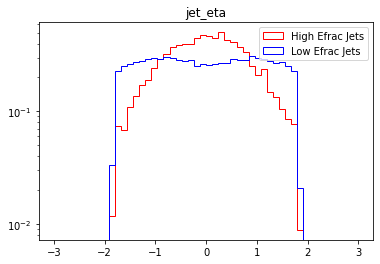

In [8]:
plt.title("jet_eta")
jet_eta=np.array(jet_eta)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_eta[jet_Efrac>0.2],bins=50,range=(-3,3),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_eta[jet_Efrac<=0.2],bins=50,range=(-3,3),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

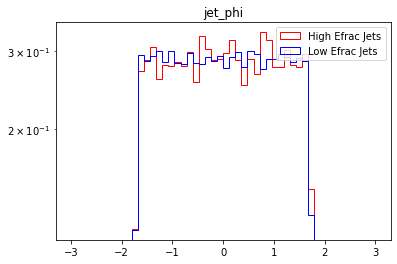

In [9]:
plt.title("jet_phi")
jet_phi=np.array(jet_phi)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_phi[jet_Efrac>0.2],bins=50,range=(-3,3),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_phi[jet_Efrac<=0.2],bins=50,range=(-3,3),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

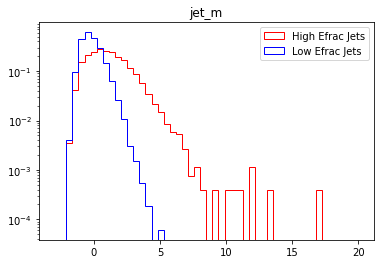

In [10]:
plt.title("jet_m")
jet_m=np.array(jet_m)
jet_Efrac=np.array(jet_Efrac)
plt.hist(jet_m[jet_Efrac>0.2],bins=50,range=(-3,20),histtype='step',color='r',label="High Efrac Jets",density=True)
plt.hist(jet_m[jet_Efrac<=0.2],bins=50,range=(-3,20),histtype='step',color='b',label="Low Efrac Jets",density=True)
plt.legend()
plt.yscale('log')
plt.show()

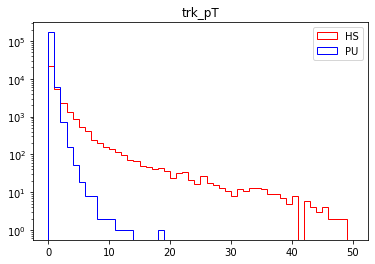

In [11]:
plt.title("trk_pT")
trk_pT=np.array(trk_pT)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_pT[trk_isPU==0],bins=50,range=(0,50),histtype='step',color='r',label="HS")
plt.hist(trk_pT[trk_isPU==1],bins=50,range=(0,50),histtype='step',color='b',label="PU")
plt.legend()
plt.yscale('log')
plt.show()

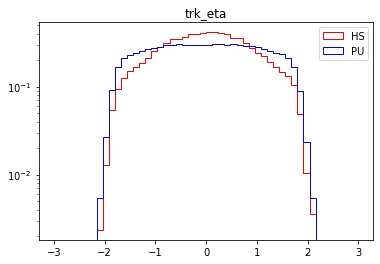

In [12]:
plt.title("trk_eta")
trk_eta=np.array(trk_eta)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_eta[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_eta[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

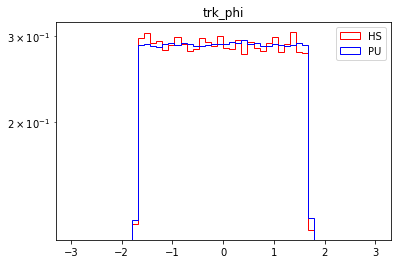

In [13]:
plt.title("trk_phi")
trk_phi=np.array(trk_phi)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_phi[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_phi[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

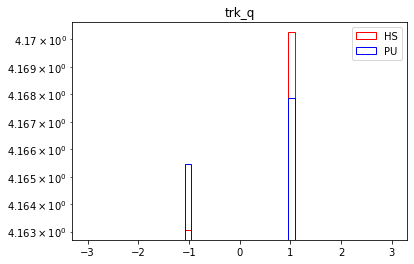

In [14]:
plt.title("trk_q")
trk_q=np.array(trk_q)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_q[trk_isPU==0],bins=50,range=(-3,3),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_q[trk_isPU==1],bins=50,range=(-3,3),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

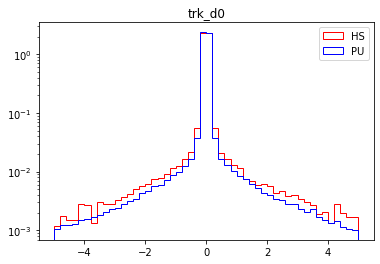

In [15]:
plt.title("trk_d0")
trk_d0=np.array(trk_d0)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_d0[trk_isPU==0],bins=50,range=(-5,5),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_d0[trk_isPU==1],bins=50,range=(-5,5),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

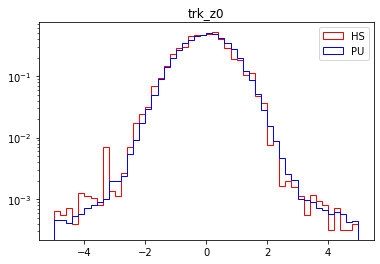

In [16]:
plt.title("trk_z0")
trk_z0=np.array(trk_z0)
trk_isPU=np.array(trk_isPU)
plt.hist(trk_z0[trk_isPU==0],bins=50,range=(-5,5),histtype='step',color='r',label="HS",density=True)
plt.hist(trk_z0[trk_isPU==1],bins=50,range=(-5,5),histtype='step',color='b',label="PU",density=True)
plt.legend()
plt.yscale('log')
plt.show()

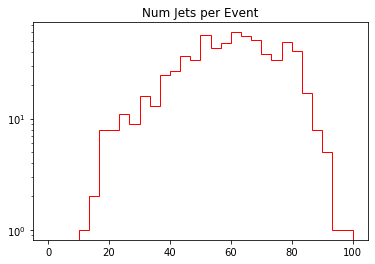

In [24]:
plt.title("Num Jets per Event")
num_jets_per_event=np.array(num_jets_in_event)
plt.hist(num_jets_per_event,bins=30,range=(0,100),histtype='step',color='r')
#plt.legend()
plt.yscale('log')
plt.show()

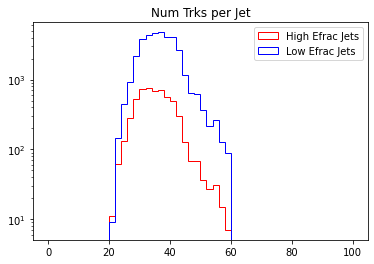

In [25]:
plt.title("Num Trks per Jet")
num_trks_per_jet=np.array(num_trks_in_jet)
jet_Efrac=np.array(jet_Efrac)
plt.hist(num_trks_per_jet[jet_Efrac>0.2],bins=50,range=(0,100),histtype='step',color='r',label="High Efrac Jets")
plt.hist(num_trks_per_jet[jet_Efrac<=0.2],bins=50,range=(0,100),histtype='step',color='b',label="Low Efrac Jets")
plt.legend()
plt.yscale('log')
plt.show()

In [26]:
print(num_trks_per_jet)

[25 25 25 ... 38 38 38]
